# Étape 8 — Prédiction de liens par méthodes structurelles classiques

Ce notebook calcule et évalue uniquement des scores topologiques à partir de `G_train`. Les
formules standard incompatibles avec une paire CV–Job sont distinguées explicitement de leurs
adaptations bipartites. Aucun score sémantique n'est chargé et aucun lien n'est ajouté au graphe.

## 1. Principe général et protocole sans fuite

La prédiction de liens par score associe à chaque paire candidate $(x,y)$ une valeur $s(x,y)$,
classe les paires par score décroissant, puis vérifie si les vrais liens cachés remontent avant les
négatifs. Nous réutilisons exactement validation et test de l'Étape 6.

`G_train` est la **seule topologie autorisée** : utiliser le graphe complet révélerait les 15 000
positifs cachés. Nous n'évaluons pas naïvement les positifs train : ils sont déjà des arêtes et leur
chemin direct de longueur 1 les rendrait incomparables aux non-arêtes validation/test. Validation
sert aux choix de $\beta$ et des seuils ; test sert uniquement à l'évaluation finale.

In [1]:
from pathlib import Path
import json
import pickle
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.sparse.linalg import eigsh
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score, roc_auc_score,
    roc_curve,
)

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures" / "step8"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with (PROCESSED_DIR / "cv_job_graph_link_train.pkl").open("rb") as file:
    G_train = pickle.load(file)
val_pairs = pd.read_csv(RESULTS_DIR / "step6_link_val_pairs.csv")
test_pairs = pd.read_csv(RESULTS_DIR / "step6_link_test_pairs.csv")

cv_nodes = sorted(n for n, d in G_train.nodes(data=True) if d.get("node_type") == "CV")
job_nodes = sorted(n for n, d in G_train.nodes(data=True) if d.get("node_type") == "Job")
cv_set, job_set = set(cv_nodes), set(job_nodes)

def verify_pairs(frame):
    assert len(frame) == 15_000
    assert frame.columns.tolist() == ["resume_id", "job_id", "label"]
    assert frame["label"].value_counts().to_dict() == {0: 7_500, 1: 7_500}
    assert not frame.duplicated(["resume_id", "job_id"]).any()
    assert frame["resume_id"].isin(cv_set).all() and frame["job_id"].isin(job_set).all()
    assert all(not G_train.has_edge(r, j) for r, j in frame[["resume_id", "job_id"]].itertuples(index=False, name=None))

assert G_train.number_of_nodes() == 12_500
assert G_train.number_of_edges() == 60_000
assert nx.is_bipartite(G_train)
verify_pairs(val_pairs)
verify_pairs(test_pairs)
print("G_train et les splits Step 6 sont validés.")

G_train et les splits Step 6 sont validés.


## 2. Pourquoi Common Neighbors et Adamic–Adar standards sont nuls

La formule standard de Common Neighbors est

$$CN(i,j)=|N(i)\cap N(j)|.$$

Dans notre graphe biparti, $N(CV)\subset Jobs$ tandis que $N(Job)\subset CV$. Les deux ensembles
sont disjoints, donc $N(CV)\cap N(Job)=\varnothing$ et Common Neighbors standard vaut toujours zéro
pour une paire CV–Job.

Adamic–Adar standard utilise les mêmes voisins communs :

$$AA(i,j)=\sum_{z\in N(i)\cap N(j)}\frac{1}{\log(deg(z))}.$$

Il est donc nul lui aussi en application directe. Nous le démontrons sur quelques paires, mais ces
zéros ne seront pas utilisés comme méthodes finales.

In [2]:
standard_demo = []
for pair in val_pairs[["resume_id", "job_id"]].head(5).itertuples(index=False, name=None):
    r, j = pair
    common = set(G_train.neighbors(r)) & set(G_train.neighbors(j))
    standard_demo.append({"resume_id": r, "job_id": j, "standard_common_neighbors": len(common)})
standard_demo_df = pd.DataFrame(standard_demo)
display(standard_demo_df)
assert (standard_demo_df["standard_common_neighbors"] == 0).all()

,resume_id,job_id,standard_common_neighbors
0,R_005320,J_001789,0
1,R_008661,J_000875,0
2,R_007458,J_000877,0
3,R_001155,J_000672,0
4,R_007950,J_002363,0


## 3. Matrice bipartite sparse

Nous représentons exactement `G_train` par une matrice $B$ de dimension
$10\,000\times2\,500$, où $B_{ij}=1$ si le CV $i$ est relié au Job $j$. Comme seules 60 000 des 25
millions de cases valent 1, un format **sparse CSR** ne stocke que les valeurs non nulles. Les
matrices intermédiaires restent sparse : aucune matrice complète volumineuse n'est convertie en
dense. Les mappings triés rendent les indices reproductibles.

In [3]:
matrix_start = time.perf_counter()
resume_to_row = {node: i for i, node in enumerate(cv_nodes)}
job_to_col = {node: j for j, node in enumerate(job_nodes)}
edge_rows, edge_cols = [], []
for u, v in G_train.edges():
    r, j = (u, v) if u in cv_set else (v, u)
    edge_rows.append(resume_to_row[r])
    edge_cols.append(job_to_col[j])

B = sparse.csr_matrix(
    (np.ones(len(edge_rows), dtype=np.int64), (edge_rows, edge_cols)),
    shape=(len(cv_nodes), len(job_nodes)),
)
assert B.shape == (10_000, 2_500)
assert B.nnz == 60_000
print("B :", B.shape, "non-zéros :", B.nnz)

B : (10000, 2500) non-zéros : 60000


## 4. Preferential Attachment — méthode standard directement valide

Le score standard d'attachement préférentiel est

$$PA(r,j)=deg(r)\times deg(j).$$

Il suppose que les nœuds déjà très connectés ont davantage tendance à recevoir de nouveaux liens.
Il ne dépend pas de voisins communs et s'applique donc directement à une paire CV–Job. Il constitue
une baseline structurelle simple.

In [4]:
cv_degree = np.asarray(B.sum(axis=1)).ravel()
job_degree = np.asarray(B.sum(axis=0)).ravel()

def pair_indices(frame):
    rows = frame["resume_id"].map(resume_to_row).to_numpy(dtype=int)
    cols = frame["job_id"].map(job_to_col).to_numpy(dtype=int)
    return rows, cols

val_rows, val_cols = pair_indices(val_pairs)
test_rows, test_cols = pair_indices(test_pairs)
pa_val = cv_degree[val_rows] * job_degree[val_cols]
pa_test = cv_degree[test_rows] * job_degree[test_cols]

## 5. Common Neighbors adapté : marches de longueur 3

Puisque le voisin commun direct est impossible, nous définissons une **adaptation bipartite inspirée
de Common Neighbors** :

$$CN3(r,j)=\sum_{r'\in N(j)} |N(r)\cap N(r')|.$$

Elle compte les marches $r\to job'\to resume'\to j$ de longueur 3. En matrices,
$B^TB$ compte les cooccurrences entre Jobs via les CV, puis

$$W_3=B(B^TB)=BB^TB.$$

Cette mesure n'est pas le Common Neighbors standard du cours ; elle est notre adaptation au graphe
biparti. Nous calculons la matrice sparse puis vérifions quelques paires par parcours explicite.

In [5]:
P_jobs = (B.T @ B).tocsr()
W3 = (B @ P_jobs).tocsr()

def sparse_values(matrix, rows, cols):
    return np.asarray(matrix[rows, cols]).ravel()

cn3_val = sparse_values(W3, val_rows, val_cols).astype(np.float64)
cn3_test = sparse_values(W3, test_rows, test_cols).astype(np.float64)

def cn3_explicit(resume_id, job_id):
    resume_jobs = set(G_train.neighbors(resume_id))
    return sum(
        len(resume_jobs & set(G_train.neighbors(other_resume)))
        for other_resume in G_train.neighbors(job_id)
    )

sample_positions = np.linspace(0, len(val_pairs) - 1, 8, dtype=int)
for position in sample_positions:
    r, j = val_pairs.loc[position, ["resume_id", "job_id"]]
    assert cn3_val[position] == cn3_explicit(r, j)
print("CN3 matriciel = CN3 explicite sur", len(sample_positions), "paires.")

CN3 matriciel = CN3 explicite sur 8 paires.


## 6. Adamic–Adar adapté par projection CV–CV

Adamic–Adar standard réduit l'influence des voisins communs très généraux par le poids
$1/\log(deg(z))$. Notre **adaptation bipartite** compare le CV candidat $r$ aux CV $r'$ déjà reliés
au Job $j$ :

$$AA_{bip}(r,j)=\sum_{r'\in N(j)}\sum_{z\in N(r)\cap N(r')}
\frac{1}{\log(deg(z))},$$

où $z$ est un Job partagé entre deux CV. Elle demande : « le CV candidat ressemble-t-il aux CV du
Job, en donnant moins de poids aux Jobs généraux ? » En matrices, nous pondérons les colonnes de $B$
par $1/\log(deg(job))$, puis multiplions par $B^TB$. Pour un degré $\le1$, le poids est fixé à zéro
afin d'éviter division par zéro ou infini.

In [6]:
aa_weights = np.zeros_like(job_degree, dtype=np.float64)
valid_degree = job_degree > 1
aa_weights[valid_degree] = 1.0 / np.log(job_degree[valid_degree])
B_weighted = B.astype(np.float64).multiply(aa_weights).tocsr()
AA_bip = (B_weighted @ P_jobs).tocsr()
aa_val = sparse_values(AA_bip, val_rows, val_cols).astype(np.float64)
aa_test = sparse_values(AA_bip, test_rows, test_cols).astype(np.float64)

def aa_bip_explicit(resume_id, job_id):
    resume_jobs = set(G_train.neighbors(resume_id))
    total = 0.0
    for other_resume in G_train.neighbors(job_id):
        for shared_job in resume_jobs & set(G_train.neighbors(other_resume)):
            degree = G_train.degree(shared_job)
            if degree > 1:
                total += 1.0 / np.log(degree)
    return total

for position in sample_positions:
    r, j = val_pairs.loc[position, ["resume_id", "job_id"]]
    assert np.isclose(aa_val[position], aa_bip_explicit(r, j), rtol=1e-10, atol=1e-10)
print("AA bipartite matriciel = calcul explicite sur", len(sample_positions), "paires.")

AA bipartite matriciel = calcul explicite sur 8 paires.


## 7. Katz standard et particularité bipartite

Le score de Katz standard additionne les marches de toutes longueurs en pénalisant les longues :

$$Katz(i,j)=\sum_{\ell=1}^{\infty}\beta^\ell(A^\ell)_{ij}.$$

$(A^\ell)_{ij}$ compte les marches de longueur $\ell$ et $\beta>0$ contrôle leur décroissance.
Dans un graphe biparti, une marche CV→Job a nécessairement une longueur **impaire**. Pour nos paires
validation/test, l'arête de longueur 1 est absente de `G_train`; les premiers signaux sont donc les
longueurs 3 puis 5.

Une inversion dense de $(I-\beta A)^{-1}$ sur 12 500 nœuds serait coûteuse. Nous utilisons un
**Katz tronqué à longueur maximale 5** :

$$Katz_5(r,j)=\beta^3W_3(r,j)+\beta^5W_5(r,j),$$

avec $W_3=B(B^TB)$ et $W_5=B(B^TB)^2=W_3(B^TB)$. Cette approximation ignore les marches 7, 9, … ;
elle ne doit pas être présentée comme le Katz infini exact.

In [7]:
W5 = (W3 @ P_jobs).tocsr()
w5_val = sparse_values(W5, val_rows, val_cols).astype(np.float64)
w5_test = sparse_values(W5, test_rows, test_cols).astype(np.float64)
matrix_seconds = time.perf_counter() - matrix_start
print("Temps matrices sparse et scores bruts :", round(matrix_seconds, 3), "s")
print("nnz P_jobs / W3 / W5 / AA :", P_jobs.nnz, W3.nnz, W5.nnz, AA_bip.nnz)

Temps matrices sparse et scores bruts : 1.336 s
nnz P_jobs / W3 / W5 / AA : 313124 2773752 3829247 2773752


## 8. Choix de $\beta$ uniquement sur validation

La série de Katz converge théoriquement si $\beta<1/\lambda_{max}$, où $\lambda_{max}$ est le rayon
spectral de l'adjacence. Pour une adjacency bipartite construite avec $B$, ce rayon est la plus grande
valeur singulière de $B$, soit la racine de la plus grande valeur propre de $B^TB$.

Nous l'estimons avec `eigsh` sur la matrice sparse et un vecteur initial fixe. Les candidats sont
$[0,1;0,3;0,5;0,7;0,9]/\lambda_{max}$ : tous sont strictement sous la borne. Pour chacun, nous
calculons ROC-AUC et Average Precision sur validation. Le meilleur ROC-AUC est retenu ; en cas
d'égalité numérique, le plus petit $\beta$ gagne de façon déterministe. Le test ne participe pas à
ce choix.

In [8]:
spectral_start = time.perf_counter()
largest_eigenvalue = float(eigsh(
    P_jobs.astype(np.float64), k=1, which="LM",
    v0=np.ones(P_jobs.shape[0]), return_eigenvectors=False,
)[0])
lambda_max = float(np.sqrt(max(largest_eigenvalue, 0.0)))
beta_fractions = [0.1, 0.3, 0.5, 0.7, 0.9]
beta_candidates = [fraction / lambda_max for fraction in beta_fractions]

beta_rows = []
for fraction, beta in zip(beta_fractions, beta_candidates):
    score = beta**3 * cn3_val + beta**5 * w5_val
    beta_rows.append({
        "fraction_of_inverse_lambda": fraction,
        "beta": float(beta),
        "val_roc_auc": float(roc_auc_score(val_pairs["label"], score)),
        "val_average_precision": float(average_precision_score(val_pairs["label"], score)),
    })
beta_results = pd.DataFrame(beta_rows)
best_beta_row = beta_results.sort_values(
    ["val_roc_auc", "beta"], ascending=[False, True]
).iloc[0]
selected_beta = float(best_beta_row["beta"])
assert selected_beta < 1.0 / lambda_max
display(beta_results)
print("lambda_max :", lambda_max)
print("beta retenu :", selected_beta)

,fraction_of_inverse_lambda,beta,val_roc_auc,val_average_precision
0,0.1,0.007175,0.941735,0.895460
1,0.3,0.021524,0.941735,0.895460
2,0.5,0.035873,0.941728,0.895461
3,0.7,0.050222,0.941780,0.895453
4,0.9,0.064571,0.941931,0.895595


lambda_max : 13.938126718702913
beta retenu : 0.06457108750434394


## 9. Scores validation et test

Nous ajoutons aux copies inchangées des splits Step 6 les quatre scores demandés. Le Katz test est
calculé seulement après gel de $\beta$. Les colonnes conservent des noms explicites pour éviter de
confondre adaptations bipartites et formules standard.

In [9]:
katz_val = selected_beta**3 * cn3_val + selected_beta**5 * w5_val
katz_test = selected_beta**3 * cn3_test + selected_beta**5 * w5_test

score_columns = {
    "Preferential Attachment": "preferential_attachment_score",
    "CN3 bipartite adapté": "bipartite_cn3_score",
    "Adamic-Adar bipartite adapté": "bipartite_adamic_adar_score",
    "Katz tronqué L=5": "truncated_katz_score",
}

classical_val = val_pairs.copy()
classical_test = test_pairs.copy()
for frame, values in [
    (classical_val, [pa_val, cn3_val, aa_val, katz_val]),
    (classical_test, [pa_test, cn3_test, aa_test, katz_test]),
]:
    for column, score in zip(score_columns.values(), values):
        frame[column] = score

classical_val.to_csv(RESULTS_DIR / "step8_classical_val_scores.csv", index=False)
classical_test.to_csv(RESULTS_DIR / "step8_classical_test_scores.csv", index=False)
display(classical_val.head())

,resume_id,job_id,label,preferential_attachment_score,bipartite_cn3_score,bipartite_adamic_adar_score,truncated_katz_score
0,R_005320,J_001789,0,130,0.0,0.000000,0.000000
1,R_008661,J_000875,1,96,2.0,0.603902,0.001123
2,R_007458,J_000877,0,66,0.0,0.000000,0.000000
3,R_001155,J_000672,1,243,4.0,1.280302,0.002234
4,R_007950,J_002363,1,115,1.0,0.318929,0.000735


## 10. Évaluation continue sans seuil

ROC-AUC mesure la qualité du classement entre positifs et négatifs ; Average Precision résume la
courbe précision-rappel. Nous les calculons séparément sur validation et test pour les quatre
méthodes classiques. Le score sémantique de l'Étape 7 n'est volontairement pas inclus : la
comparaison officielle appartient à l'Étape 9.

In [10]:
evaluation_rows = []
for method, column in score_columns.items():
    evaluation_rows.append({
        "method": method,
        "val_roc_auc": roc_auc_score(classical_val["label"], classical_val[column]),
        "test_roc_auc": roc_auc_score(classical_test["label"], classical_test[column]),
        "val_average_precision": average_precision_score(classical_val["label"], classical_val[column]),
        "test_average_precision": average_precision_score(classical_test["label"], classical_test[column]),
    })
evaluation_df = pd.DataFrame(evaluation_rows).set_index("method")
display(evaluation_df)

,val_roc_auc,test_roc_auc,val_average_precision,test_average_precision
method,,,,
Preferential Attachment,0.529080,0.525303,0.515896,0.519150
CN3 bipartite adapté,0.893604,0.895914,0.852316,0.859160
Adamic-Adar bipartite adapté,0.893711,0.896257,0.852776,0.861062
Katz tronqué L=5,0.941931,0.944535,0.895595,0.903252


## 11. Seuils de classification choisis sur validation

Les scores structurels sont souvent discrets et comportent de nombreuses égalités ; une grille
linéaire 0–1 serait inadaptée. `precision_recall_curve` évalue efficacement les **valeurs uniques
observées en validation** comme seuils. Pour chaque méthode, nous retenons le seuil maximisant F1
validation, le gelons, puis l'appliquons au test pour calculer Precision, Recall, F1, accuracy et
matrice de confusion. Aucun seuil n'est ajusté avec le test.

In [11]:
def select_threshold_on_validation(labels, scores):
    precision, recall, thresholds = precision_recall_curve(labels, scores)
    f1_values = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-15)
    best = int(np.argmax(f1_values))
    return float(thresholds[best]), float(f1_values[best])

threshold_summary = {}
threshold_rows = []
for method, column in score_columns.items():
    threshold, val_best_f1 = select_threshold_on_validation(
        classical_val["label"].to_numpy(), classical_val[column].to_numpy()
    )
    prediction = (classical_test[column].to_numpy() >= threshold).astype(int)
    metrics = {
        "selected_threshold": threshold,
        "validation_f1_at_selection": val_best_f1,
        "test_precision": float(precision_score(classical_test["label"], prediction, zero_division=0)),
        "test_recall": float(recall_score(classical_test["label"], prediction, zero_division=0)),
        "test_f1": float(f1_score(classical_test["label"], prediction, zero_division=0)),
        "test_accuracy": float(accuracy_score(classical_test["label"], prediction)),
        "test_confusion_matrix": confusion_matrix(classical_test["label"], prediction).tolist(),
    }
    threshold_summary[method] = metrics
    threshold_rows.append({"method": method, **{k: v for k, v in metrics.items() if k != "test_confusion_matrix"}})
threshold_df = pd.DataFrame(threshold_rows).set_index("method")
display(threshold_df)

,selected_threshold,validation_f1_at_selection,test_precision,test_recall,test_f1,test_accuracy
method,,,,,,
Preferential Attachment,18.000000,0.667557,0.500534,1.000000,0.667141,0.501067
CN3 bipartite adapté,1.000000,0.891809,0.895096,0.890800,0.892943,0.893200
Adamic-Adar bipartite adapté,0.296974,0.891868,0.895096,0.890800,0.892943,0.893200
Katz tronqué L=5,0.000055,0.940674,0.895171,0.998533,0.944031,0.940800


## 12. Distributions et courbes des méthodes classiques

Les histogrammes comparent positifs et négatifs pour chaque score test. La courbe ROC regroupe les
quatre méthodes avec leurs noms complets : CN3 et Adamic–Adar sont des adaptations bipartites, Katz
est tronqué à $L=5$. Ces figures restent exclusivement structurelles.

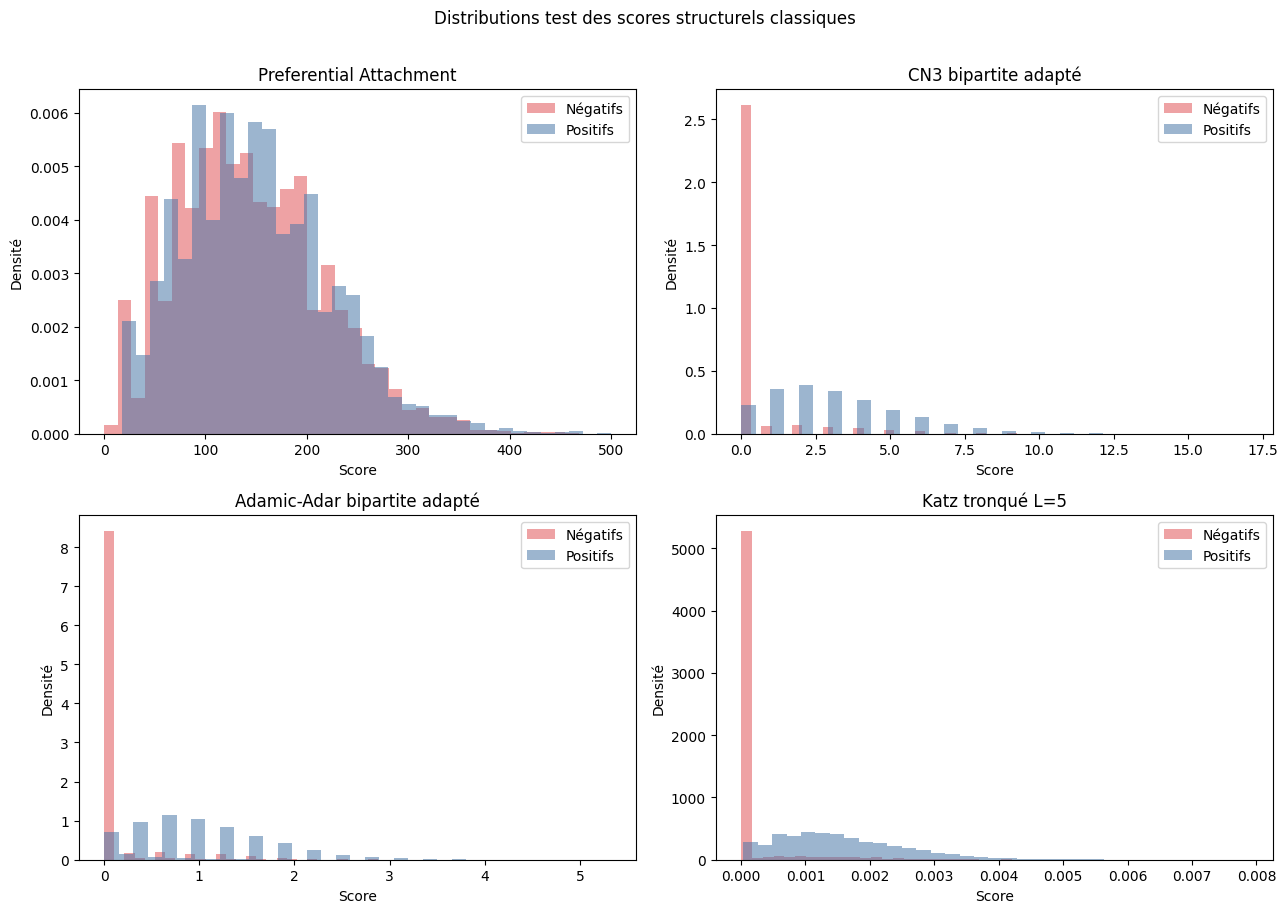

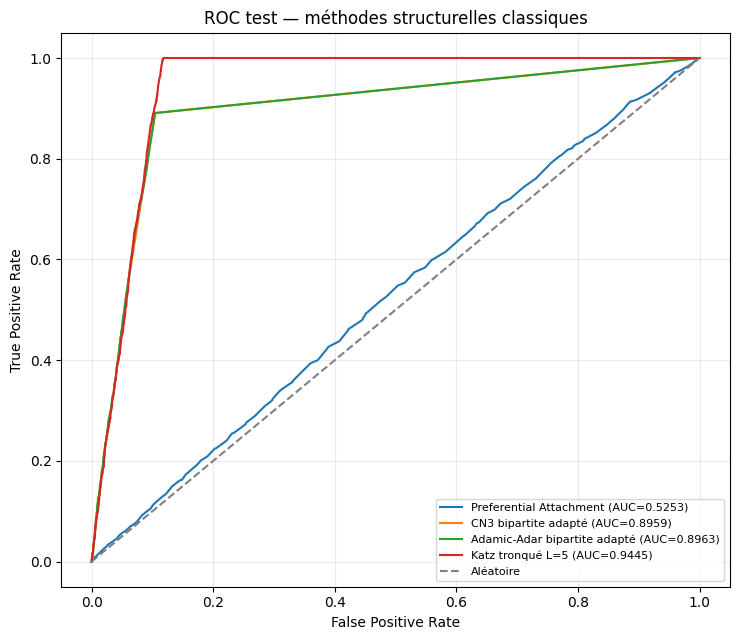

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (method, column) in zip(axes.ravel(), score_columns.items()):
    for label, color, name in [(0, "#E15759", "Négatifs"), (1, "#4C78A8", "Positifs")]:
        ax.hist(classical_test.loc[classical_test["label"] == label, column], bins=35, alpha=0.55, density=True, color=color, label=name)
    ax.set_title(method)
    ax.set_xlabel("Score")
    ax.set_ylabel("Densité")
    ax.legend()
fig.suptitle("Distributions test des scores structurels classiques", y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "classical_score_distributions_test.png", dpi=170, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
for method, column in score_columns.items():
    fpr, tpr, _ = roc_curve(classical_test["label"], classical_test[column])
    auc = evaluation_df.loc[method, "test_roc_auc"]
    ax.plot(fpr, tpr, label=f"{method} (AUC={auc:.4f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Aléatoire")
ax.set(title="ROC test — méthodes structurelles classiques", xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "classical_roc_test.png", dpi=170, bbox_inches="tight")
plt.show()

## 13. Paires sans signal structurel court

Un score CN3, Adamic–Adar adapté ou Katz tronqué nul signifie qu'aucune marche courte de longueur 3
ou 5 ne relie la paire dans `G_train` selon la méthode. Cela ne prouve pas l'incompatibilité : la
paire peut appartenir à des composantes différentes, concerner un CV isolé préexistant, ou nécessiter
des chemins plus longs que notre approximation. Nous comparons les taux de zéro chez positifs et
négatifs pour voir si les vrais liens cachés disposent plus souvent d'un signal court.

In [13]:
zero_columns = ["bipartite_cn3_score", "bipartite_adamic_adar_score", "truncated_katz_score"]
zero_rows = []
for split_name, frame in [("validation", classical_val), ("test", classical_test)]:
    for column in zero_columns:
        for label in [0, 1]:
            subset = frame.loc[frame["label"] == label, column]
            zero_rows.append({
                "split": split_name, "score": column, "label": label,
                "zero_fraction": float(np.isclose(subset, 0.0).mean()),
            })
zero_df = pd.DataFrame(zero_rows)
display(zero_df.pivot_table(index=["score", "label"], columns="split", values="zero_fraction"))

split                                  test  validation
score                       label                      
bipartite_adamic_adar_score 0      0.895600    0.892400
                            1      0.109200    0.108667
bipartite_cn3_score         0      0.895600    0.892400
                            1      0.109200    0.108667
truncated_katz_score        0      0.856533    0.849067
                            1      0.000000    0.000000

## 14. Exemples interprétables

Nous affichons des positifs très bien scorés, des positifs sans/faible signal et des négatifs très
bien scorés selon le meilleur score classique test. Les attributs servent uniquement à interpréter
les situations ; aucun paramètre n'est modifié après observation du test.

In [14]:
best_classical_method = evaluation_df["test_roc_auc"].idxmax()
best_classical_column = score_columns[best_classical_method]

def enrich_examples(frame):
    rows = []
    for item in frame.itertuples(index=False):
        cv = G_train.nodes[item.resume_id]
        job = G_train.nodes[item.job_id]
        rows.append({
            "resume_id": item.resume_id, "job_id": item.job_id, "label": item.label,
            "score": getattr(item, best_classical_column),
            "cv_role": cv.get("role"), "cv_seniority": cv.get("seniority"), "cv_industry": cv.get("industry"),
            "job_title": job.get("job_title"), "job_seniority": job.get("seniority"), "job_industry": job.get("industry"),
        })
    return pd.DataFrame(rows)

positive_test = classical_test[classical_test["label"] == 1]
negative_test = classical_test[classical_test["label"] == 0]
print("Meilleure méthode classique selon ROC-AUC test :", best_classical_method)
print("Positifs au score élevé")
display(enrich_examples(positive_test.nlargest(8, best_classical_column)))
print("Positifs au score faible")
display(enrich_examples(positive_test.nsmallest(8, best_classical_column)))
print("Négatifs au score élevé")
display(enrich_examples(negative_test.nlargest(8, best_classical_column)))

Meilleure méthode classique selon ROC-AUC test : Katz tronqué L=5
Positifs au score élevé


,resume_id,job_id,label,score,cv_role,cv_seniority,cv_industry,job_title,job_seniority,job_industry
0,R_008783,J_001111,1,0.007867,Operations Manager,Mid,Retail,Project Manager,Junior,Logistics
1,R_008568,J_000400,1,0.006369,Business Analyst,Mid,Retail,Business Analyst,Mid,SaaS
2,R_009531,J_000291,1,0.006304,Business Development Manager,Senior,Retail,Account Executive,Mid,Gaming
3,R_006582,J_002085,1,0.006221,Technical Support Specialist,Mid,FinTech,Customer Support Specialist,Mid,Retail
4,R_005456,J_001966,1,0.005960,Junior Accountant,Junior,Cybersecurity,FP&A Analyst,Mid,Travel
5,R_003229,J_000736,1,0.005892,Technical Support Specialist,Senior,Cybersecurity,Customer Success Associate,Mid,EdTech
6,R_008358,J_000015,1,0.005524,Customer Success Associate,Senior,EdTech,Customer Success Associate,Senior,Retail
7,R_009350,J_002416,1,0.005474,Backend Engineer,Junior,EdTech,Full Stack Engineer,Junior,Retail


Positifs au score faible


,resume_id,job_id,label,score,cv_role,cv_seniority,cv_industry,job_title,job_seniority,job_industry
0,R_004468,J_001424,1,0.000036,Full Stack Engineer,Mid,Logistics,Full Stack Engineer,Junior,Logistics
1,R_002543,J_000097,1,0.000042,Backend Engineer,Junior,Healthcare,Software Engineer,Senior,EdTech
2,R_001170,J_001395,1,0.000043,Content Marketer,Mid,Gaming,Performance Marketer,Mid,Healthcare
3,R_005143,J_002467,1,0.000044,Project Manager,Junior,FinTech,Program Coordinator,Junior,Healthcare
4,R_002544,J_001662,1,0.000045,Technical Product Manager,Mid,Healthcare,Associate Product Manager,Mid,FinTech
5,R_008927,J_000165,1,0.000046,Program Coordinator,Junior,Travel,Operations Manager,Junior,FinTech
6,R_001759,J_002009,1,0.000049,Technical Product Manager,Junior,Logistics,Associate Product Manager,Mid,FinTech
7,R_008472,J_000701,1,0.000053,Product Manager,Junior,Retail,Product Manager,Junior,Retail


Négatifs au score élevé


,resume_id,job_id,label,score,cv_role,cv_seniority,cv_industry,job_title,job_seniority,job_industry
0,R_005456,J_002059,0,0.005886,Junior Accountant,Junior,Cybersecurity,Financial Analyst,Mid,Healthcare
1,R_003525,J_000524,0,0.005165,Business Development Manager,Mid,Retail,Sales Representative,Senior,EdTech
2,R_008825,J_000372,0,0.004570,Technical Product Manager,Senior,E-commerce,Product Manager,Junior,SaaS
3,R_000683,J_001137,0,0.004479,Operations Manager,Mid,FinTech,Program Coordinator,Senior,Retail
4,R_006842,J_001316,0,0.004429,Associate Product Manager,Junior,Retail,Product Manager,Senior,EdTech
5,R_000137,J_002026,0,0.004377,Business Analyst,Mid,Gaming,BI Analyst,Senior,FinTech
6,R_000148,J_002289,0,0.004361,Customer Support Specialist,Senior,Travel,Customer Support Specialist,Junior,Cybersecurity
7,R_003229,J_001050,0,0.004353,Technical Support Specialist,Senior,Cybersecurity,Customer Support Specialist,Mid,Gaming


## 15. Assertions finales anti-fuite et de validité

Ces contrôles garantissent que les scores proviennent exclusivement de `G_train`, que les splits
sont inchangés, que toutes les paires sont des non-arêtes CV–Job, que les adaptations matricielles
ont été vérifiées explicitement et que $\beta$/les seuils proviennent seulement de validation. Un
échec arrête le notebook.

In [15]:
assert G_train.number_of_edges() == 60_000
for original, scored in [(val_pairs, classical_val), (test_pairs, classical_test)]:
    pd.testing.assert_frame_equal(original, scored[["resume_id", "job_id", "label"]])
    assert all(not G_train.has_edge(r, j) for r, j in original[["resume_id", "job_id"]].itertuples(index=False, name=None))
    assert original["resume_id"].isin(cv_set).all() and original["job_id"].isin(job_set).all()
    assert np.isfinite(scored[list(score_columns.values())].to_numpy()).all()
assert (standard_demo_df["standard_common_neighbors"] == 0).all()
assert selected_beta in beta_candidates and selected_beta < 1 / lambda_max
assert set(threshold_summary) == set(score_columns)
print("Toutes les assertions sont passées.")

Toutes les assertions sont passées.


## 16. Résumé reproductible

Le JSON conserve les adaptations, la borne spectrale, tous les candidats $\beta$, les métriques,
les seuils issus de validation, les proportions de zéros et les temps. Il confirme explicitement
l'absence de fuite et l'absence de score sémantique.

In [16]:
total_seconds = time.perf_counter() - matrix_start
summary = {
    "methods": list(score_columns.keys()),
    "graph_source": "data/processed/cv_job_graph_link_train.pkl",
    "n_train_graph_edges": int(G_train.number_of_edges()),
    "n_val_pairs": int(len(val_pairs)),
    "n_test_pairs": int(len(test_pairs)),
    "lambda_max": lambda_max,
    "inverse_lambda_bound": float(1 / lambda_max),
    "beta_candidates": [float(x) for x in beta_candidates],
    "beta_validation_results": beta_rows,
    "selected_beta": selected_beta,
    "beta_selection_split": "validation",
    "beta_selection_metric": "ROC-AUC",
    "katz_max_length": 5,
    "continuous_metrics": {method: {k: float(v) for k, v in row.items()} for method, row in evaluation_df.to_dict(orient="index").items()},
    "threshold_metrics": threshold_summary,
    "zero_score_proportions": zero_rows,
    "best_classical_method_by_test_roc_auc": best_classical_method,
    "sparse_matrix_nonzeros": {"B": int(B.nnz), "P_jobs": int(P_jobs.nnz), "W3": int(W3.nnz), "W5": int(W5.nnz), "AA_bip": int(AA_bip.nnz)},
    "matrix_and_raw_score_seconds": float(matrix_seconds),
    "total_notebook_computation_seconds_from_matrix_start": float(total_seconds),
    "bipartite_adaptations_confirmed": {
        "common_neighbors": "length-3 walk count, not standard Common Neighbors",
        "adamic_adar": "resume-projection aggregation weighted by shared-job degree, not direct CV-Job Adamic-Adar",
        "katz": "truncated odd walks of lengths 3 and 5, not infinite Katz",
    },
    "anti_leakage_confirmed": True,
    "step6_splits_reused_unchanged": True,
    "test_used_for_hyperparameter_selection": False,
    "semantic_scores_loaded": False,
    "all_assertions_passed": True,
}
(RESULTS_DIR / "step8_classical_link_prediction_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8"
)
print("Résumé sauvegardé. Temps total mesuré :", round(total_seconds, 3), "s")

Résumé sauvegardé. Temps total mesuré : 4.902 s


## Interprétation et conclusion

- **Preferential Attachment est peu informatif** : ROC-AUC test `0,5253` et Average Precision
  `0,5192`, à peine au-dessus d'un classement aléatoire sur ce benchmark équilibré. Son seuil
  validation prédit presque toutes les paires positives (Recall `1`) mais avec une Precision proche
  de `0,5`; les produits de degrés ne suffisent donc pas à distinguer les matches.
- **CN3 bipartite adapté sépare fortement les classes** : ROC-AUC test `0,8959`, Average Precision
  `0,8592` et F1 test `0,8929` au seuil validation `1`. Les vrais liens cachés ont beaucoup plus
  souvent une marche de longueur 3 : seulement `10,92 %` des positifs test ont CN3 nul, contre
  `89,56 %` des négatifs.
- **Adamic–Adar bipartite adapté améliore légèrement le classement** de CN3 : ROC-AUC test `0,8963`
  et Average Precision `0,8611`. Le gain reste faible, et son meilleur seuil produit exactement la
  même matrice de confusion que CN3 (`6 681` vrais positifs, `6 717` vrais négatifs). Les degrés des
  Jobs partagés sont assez homogènes dans ce dataset synthétique, ce qui limite l'effet de la
  pondération logarithmique.
- **Katz tronqué L=5 est la meilleure méthode classique de cette étape** : ROC-AUC test `0,9445`,
  Average Precision `0,9033` et F1 test `0,9440`. Au seuil choisi sur validation, il atteint
  Precision `0,8952` et Recall `0,9985` (seulement 11 faux négatifs). Les marches de longueur 5
  apportent un signal à tous les positifs test, alors que `85,65 %` des négatifs gardent un score
  nul.
- Le rayon spectral estimé vaut `13,9381`, donc la borne est `1/λ≈0,07175`. La validation retient
  $\beta=0,064571$ (`0,9/λ`), celui qui maximise sa ROC-AUC parmi les cinq candidats. Ce paramètre a
  été gelé avant le calcul test.
- Les paires sans score court ne sont pas nécessairement incompatibles : elles peuvent appartenir à
  des zones séparées de `G_train`, concerner un CV isolé préexistant ou nécessiter une marche plus
  longue. Le caractère biparti interdit les voisins communs CV–Job directs et oblige donc ces
  adaptations par marches impaires ou projection.
- Enfin, `Katz_5` reste une approximation : il ignore les marches de longueur 7 et plus et compte des
  marches, y compris avec retours, plutôt que seulement des chemins simples. Son avantage observé ne
  prouve pas que le Katz infini exact aurait le même classement.

Les calculs sparse et l'évaluation ont pris environ **5,7 secondes** dans cet environnement. Aucun
score sémantique n'a été chargé, aucune comparaison finale semantic/structural n'a été effectuée et
aucun lien n'a été ajouté au graphe.